/home/santo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Eğitime Girecek Özellik Sayısı: 53
🚀 Sadece Ajan ve Harita Bilgisiyle Doğruluk Oranı (Accuracy): %61.11
✅ Yeni Maç Öncesi Modeli ve Sütun Yapısı başarıyla kaydedildi!


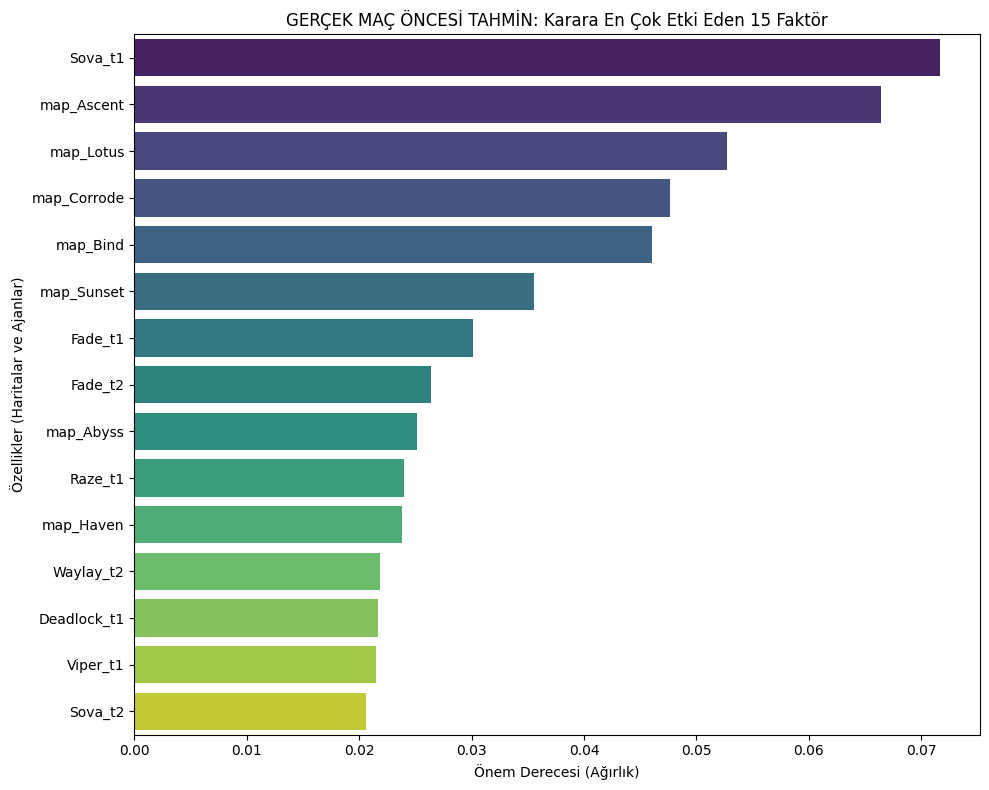

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# 1. VERİLERİ OKUMA VE BİRLEŞTİRME
matches_df = pd.read_csv('data/matches.csv')
maps_df = pd.read_csv('data/detailed_matches_maps.csv')
player_df = pd.read_csv('data/detailed_matches_player_stats.csv')

merged_df = pd.merge(matches_df, maps_df, on='match_id', how='inner')
merged_df['team1_won_map'] = (merged_df['winner_y'] == merged_df['team1']).astype(int)

# 2. AJANLARI İŞLEME VE DÜZELTME
player_df['agent'] = player_df['agent'].astype(str).str.split(',').str[0].str.strip()
agent_picks = player_df[['match_id', 'player_team', 'agent']].rename(columns={'player_team': 'team'})
agent_dummies = pd.get_dummies(agent_picks, columns=['agent'], prefix='', prefix_sep='')
team_agents = agent_dummies.groupby(['match_id', 'team']).max().reset_index()

merged_df = pd.merge(merged_df, team_agents, left_on=['match_id', 'team1'], right_on=['match_id', 'team'], how='left')
merged_df = pd.merge(merged_df, team_agents, left_on=['match_id', 'team2'], right_on=['match_id', 'team'], how='left', suffixes=('_t1', '_t2'))

# 3. HARİTALARI İŞLEME (ONE-HOT ENCODING)
map_dummies = pd.get_dummies(merged_df['map_name'], prefix='map')
merged_df = pd.concat([merged_df, map_dummies], axis=1)

# 4. SÜTUNLARI AYIRMA
map_cols = list(map_dummies.columns)
t1_agent_cols = [col for col in merged_df.columns if col.endswith('_t1') and col != 'team_t1']
t2_agent_cols = [col for col in merged_df.columns if col.endswith('_t2') and col != 'team_t2']

# =========================================================================
# 5. SİMETRİK VERİ ÜRETİMİ (AYNA EŞLEŞMESİ SORUNUNU %100 ÇÖZER!)
# =========================================================================
# Normal Maçlar
df_normal = merged_df[map_cols + t1_agent_cols + t2_agent_cols].copy()
df_normal['target'] = merged_df['team1_won_map']

# Ters Çevrilmiş Maçlar (T2 ve T1 sütunlarını bilerek yer değiştiriyoruz)
df_swapped = merged_df[map_cols + t2_agent_cols + t1_agent_cols].copy()
# İsimleri tekrar normal düzene getiriyoruz ki model aynı sütunları görsün
df_swapped.columns = map_cols + t1_agent_cols + t2_agent_cols
# T1 kaybettiyse 0'dı, ters çevirince Swapped T1 (eski T2) kazandı yani 1 olmalı
df_swapped['target'] = 1 - merged_df['team1_won_map'] 

# İki dataframe'i üst üste birleştiriyoruz. Veri seti 2 katına çıktı!
df_symmetric = pd.concat([df_normal, df_swapped], ignore_index=True)

df_symmetric = df_symmetric.fillna(0)
bool_cols = df_symmetric.select_dtypes(include=['bool']).columns
df_symmetric[bool_cols] = df_symmetric[bool_cols].astype(int)

X = df_symmetric.drop('target', axis=1)
y = df_symmetric['target']

# 6. EĞİTİM VE TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"🚀 Simetrik Model Doğruluk Oranı: %{accuracy_score(y_test, model.predict(X_test)) * 100:.2f}")

joblib.dump(model, 'valorant_rf_model.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')
print("✅ Model ve Sütunlar Kaydedildi!")

# =========================================================================
# 7. HARİTAYA ÖZEL AJAN İSTATİSTİKLERİ ÇIKARMA
# =========================================================================
map_agent_stats = {}
for m_col in map_cols:
    map_name = m_col.replace('map_', '')
    map_data = merged_df[merged_df[m_col] == 1] # Sadece bu haritada oynanan maçlar
    
    agent_win_rates = {}
    for agent_col in t1_agent_cols:
        agent_name = agent_col.replace('_t1', '')
        agent_played = map_data[map_data[agent_col] == 1]
        
        # En az 10 maç oynanmış ajanları ciddiye al (istatistiksel tutarlılık için)
        if len(agent_played) > 10: 
            win_rate = agent_played['team1_won_map'].mean() * 100
            agent_win_rates[agent_name] = round(win_rate, 1)
            
    # Kazanma oranına göre büyükten küçüğe sırala ve en iyi 5 ajanı al
    sorted_agents = sorted(agent_win_rates.items(), key=lambda item: item[1], reverse=True)[:5]
    map_agent_stats[map_name] = sorted_agents

joblib.dump(map_agent_stats, 'map_agent_stats.pkl')
print("✅ Haritaya Özel Ajan İstatistikleri (map_agent_stats.pkl) Kaydedildi!")